# ANN Orchestrator For Multi-Run Ensembling and Checkpointing

This notebook defines a reusable orchestrator that:
1. Configures a set of runs (architectures, hyperparameters, number of seeds).
2. Runs expanding-window forecasts and top-k ensembling (same logic as `compute_top_k_ensemble`).
3. Saves model checkpoints at each refit step (DeepSHAP-friendly: torch `state_dict` + preprocessing state).
4. Saves performance tuples per maturity: `(maturity, r2_oos, rsz_pval)`.

The example at the bottom runs a simple forward-only ANN with `n_models=10` and `k_top=1`.

In [7]:
import os
import sys
from pathlib import Path
from dataclasses import dataclass, asdict
from datetime import datetime
from typing import Callable, Any

import numpy as np
import pandas as pd
import torch
import statsmodels.api as sm
from scipy.stats import t as tstat
from tqdm.auto import tqdm

sys.path.insert(0, os.path.abspath('..'))

import utils.base_utils as bu
import utils.window_utils as wu
from utils.macro_grouping import add_group_level, build_full_group_mapping
from models.ann_vector_validation import PyTorchMLPWrapper
from models.macro_forward_ann import MacroForwardANNWrapper

# Data prep
start_date = '1971-08-31'
end_date = '2018-12-31'
maturities = ['120']

yields = bu.get_yields(type='lw', start=start_date, end=end_date, maturities=[str(i) for i in range(12, 121) if i % 12 == 0])
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna()
fred_md_raw = bu.get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date)

fred_md = bu.apply_fred_md_publication_lag(fred_md_raw).bfill()
yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1, keys=['fred', 'forward', 'yields'])
X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')

y_all = xr[maturities].values
dates = xr.index

In [2]:
from utils.orchestrator_runs import RunConfig, run_experiment

Main block for running:

In [4]:
nodes = [3, 5]
architectures = [(h,) for h in nodes] + [(h, h) for h in nodes]

def arch_to_name(arch):
    return "&".join(str(x) for x in arch)

def make_fwd_ann_cfg(arch, n_models=100, k_top=10):
    return RunConfig(
        run_name=f"fwd_ann_{arch_to_name(arch)}_{n_models}runs_top{k_top}",
        model_builder=lambda seed, arch=arch: PyTorchMLPWrapper(
        archi=arch,
        lr=0.01,
        epochs=1000,
        tune_every=60,
        patience=50,
        param_grid={"penalty": [0.01, 0.001, 0.0001]},
        seed=seed,
        use_pca=False,
        n_components=None,
        y_center=False,
        ),
        n_models=n_models,
        k_top=k_top,
        maturities=maturities,
        oos_start=pd.Timestamp("1990-01-31"),
        gap=0,
        refit_freq=1,
        benchmark="hist_mean",
        progress=True,
        )

run_configs = [make_fwd_ann_cfg(arch, n_models = 5, k_top = 2) for arch in architectures]

all_summaries = []
for cfg in run_configs:
    print(f"Running {cfg.run_name} ...")
    all_summaries.append(run_experiment(cfg, X, y_all, dates))

Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running fwd_ann_3_5runs_top2 ...


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running fwd_ann_5_5runs_top2 ...


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running fwd_ann_3&3_5runs_top2 ...


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running fwd_ann_5&5_5runs_top2 ...


Seeds: 100%|██████████| 5/5 [02:52<00:00, 34.54s/it]


In [10]:
def make_macro_forward_ann_cfg(arch, n_models=100, k_top=10):
    return RunConfig(
        run_name=f"macro_forward_ann_{arch_to_name(arch)}_{n_models}runs_top{k_top}",
        model_builder=lambda seed, arch=arch: MacroForwardANNWrapper(
            archi_forward=arch,
            archi_macro=arch,   # keep same structure as forward ANN for now
            lr=0.01,
            epochs=1000,
            tune_every=60,
            patience=50,
            param_grid={
                "penalty": [0.01, 0.001, 0.0001],
                "dropout_rate": [0.0, 0.1, 0.2],
            },
            seed=seed,
            y_center=False,
        ),
        n_models=n_models,
        k_top=k_top,
        maturities=maturities,
        oos_start=pd.Timestamp("1990-01-31"),
        gap=0,
        refit_freq=1,
        benchmark="hist_mean",
        progress=True,
    )

In [ ]:
run_configs = [
    make_macro_forward_ann_cfg(arch, n_models=5, k_top=2)
    for arch in architectures
]

all_summaries = []
for cfg in run_configs:
    print(f"Running {cfg.run_name} ...")
    all_summaries.append(run_experiment(cfg, X, y_all, dates))

Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running macro_forward_ann_3_5runs_top2 ...


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running macro_forward_ann_5_5runs_top2 ...


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running macro_forward_ann_3&3_5runs_top2 ...


Seeds:   0%|          | 0/5 [00:00<?, ?it/s]

Running macro_forward_ann_5&5_5runs_top2 ...


Seeds:  40%|████      | 2/5 [03:33<05:41, 113.88s/it]

In [8]:
import importlib
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import shap

# =========================================================
# SETTINGS
# =========================================================
artifacts_root = Path("../artifacts/orchestrator_runs")
run_name = "fwd_ann_5&5_5runs_top2"   # <- change this to your actual run folder
run_timestamp = None                # None = latest timestamp folder
background_size = 32                # small for testing

# test only a few dates first
test_dates = [
    "2010-01-31",
    "2013-02-28",
    "2015-03-31",
]

# test only a few maturities first
test_maturities = ["120"]           # e.g. ["24", "120"]

output_csv_name = "topk_mean_shap_test.csv"

# =========================================================
# HELPERS
# =========================================================
def resolve_run_dir(base_dir: Path, run_name: str, run_timestamp: str | None = None) -> Path:
    run_root = base_dir / run_name
    if not run_root.exists():
        raise FileNotFoundError(f"Run root does not exist: {run_root}")

    if run_timestamp is not None:
        run_dir = run_root / run_timestamp
        if not run_dir.exists():
            raise FileNotFoundError(f"Requested run timestamp not found: {run_dir}")
        return run_dir

    candidates = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No timestamped runs found under: {run_root}")
    return candidates[-1]


def apply_saved_preprocessing(X_raw, scaler_state, pca_state):
    Xp = np.asarray(X_raw, dtype=np.float32).copy()

    if scaler_state is not None:
        mean = scaler_state.get("mean_", None)
        scale = scaler_state.get("scale_", None)

        if mean is not None:
            Xp = Xp - np.asarray(mean, dtype=np.float32)

        if scale is not None:
            scale = np.asarray(scale, dtype=np.float32)
            scale = np.where(scale == 0.0, 1.0, scale)
            Xp = Xp / scale

    if pca_state is not None and pca_state.get("components_", None) is not None:
        pca_mean = pca_state.get("mean_", None)
        if pca_mean is not None:
            Xp = Xp - np.asarray(pca_mean, dtype=np.float32)
        comps = np.asarray(pca_state["components_"], dtype=np.float32)
        Xp = Xp @ comps.T

    return Xp


def rebuild_model_from_checkpoint(checkpoint):
    state_dict = checkpoint["torch_state_dict"]

    linear_keys = [
        k for k, v in state_dict.items()
        if k.endswith(".weight") and getattr(v, "ndim", 0) == 2
    ]
    linear_keys = sorted(linear_keys, key=lambda k: int(k.split(".")[1]))

    if len(linear_keys) < 2:
        raise RuntimeError("Could not infer architecture from checkpoint.")

    in_dim = int(state_dict[linear_keys[0]].shape[1])
    out_dim = int(state_dict[linear_keys[-1]].shape[0])
    hidden_arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys[:-1])

    ann_mod = importlib.import_module("models.ann_vector_validation")
    NetworkCls = getattr(ann_mod, "_MLPNetwork")

    model = NetworkCls(input_dim=in_dim, archi=hidden_arch, output_dim=out_dim)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def extract_shap_vector(shap_values, maturity_index):
    if isinstance(shap_values, list):
        sv = np.asarray(shap_values[maturity_index])[0]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # shape often: (n_samples, n_features, n_outputs)
        sv = shap_values[0, :, maturity_index]
    else:
        sv = np.asarray(shap_values)[0]

    return np.asarray(sv, dtype=float).reshape(-1)


# =========================================================
# ASSUMES THESE ALREADY EXIST FROM YOUR EARLIER CELLS:
#   X
#   dates
#   maturities
# =========================================================

X_forward = X["forward"].values
raw_feature_names = [
    col if isinstance(col, str) else " | ".join(map(str, col))
    for col in X["forward"].columns
]

# =========================================================
# LOAD RUN ARTIFACTS
# =========================================================
run_dir = resolve_run_dir(artifacts_root, run_name, run_timestamp)
manifest = pd.read_csv(run_dir / "checkpoint_manifest.csv")
topk_indices = np.load(run_dir / "topk_indices.npy")

rows = []

for dt_str in test_dates:
    matches = np.where(pd.to_datetime(dates) == pd.Timestamp(dt_str))[0]
    if len(matches) == 0:
        print(f"Skipping missing date: {dt_str}")
        continue

    t_idx = int(matches[0])

    for maturity in test_maturities:
        if maturity not in maturities:
            print(f"Skipping missing maturity: {maturity}")
            continue

        m_idx = maturities.index(maturity)

        seed_candidates = topk_indices[t_idx, m_idx, :]
        selected_seeds = [int(s) for s in seed_candidates if int(s) >= 0]

        if len(selected_seeds) == 0:
            print(f"No valid top-k seeds for date={dt_str}, maturity={maturity}")
            continue

        seed_shap_rows = []
        feature_names_this = None

        for seed in selected_seeds:
            row = manifest[(manifest["seed"] == seed) & (manifest["t_index"] == t_idx)]
            if row.empty:
                print(f"Missing checkpoint in manifest for seed={seed}, t_idx={t_idx}")
                continue

            ckpt_path = Path(row.iloc[0]["checkpoint_path"])
            checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

            if checkpoint.get("wrapper_class") != "PyTorchMLPWrapper":
                print(f"Skipping non-MLP checkpoint: {ckpt_path}")
                continue

            model = rebuild_model_from_checkpoint(checkpoint)

            X_proc = apply_saved_preprocessing(
                X_forward,
                checkpoint.get("x_scaler", None),
                checkpoint.get("pca", None),
            )

            train_end = max(1, t_idx)
            bg_start = max(0, train_end - background_size)

            X_bg = X_proc[bg_start:train_end]
            X_eval = X_proc[t_idx:t_idx + 1]

            if X_bg.shape[0] < 2:
                print(f"Not enough background rows for date={dt_str}")
                continue

            bg_tensor = torch.tensor(X_bg, dtype=torch.float32)
            eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

            explainer = shap.DeepExplainer(model, bg_tensor)
            shap_values = explainer.shap_values(eval_tensor)

            sv = extract_shap_vector(shap_values, m_idx)
            seed_shap_rows.append(sv)

            if len(raw_feature_names) == len(sv):
                feature_names_this = raw_feature_names
            else:
                feature_names_this = [f"PC{i+1}" for i in range(len(sv))]

        if len(seed_shap_rows) == 0:
            print(f"No SHAP rows computed for date={dt_str}, maturity={maturity}")
            continue

        shap_mat = np.vstack(seed_shap_rows)

        # Mean of signed SHAP values across selected models
        mean_sv = np.mean(shap_mat, axis=0)

        # Mean of absolute SHAP values across selected models
        abs_mean_sv = np.mean(np.abs(shap_mat), axis=0)

        for feat, mean_val, abs_mean_val in zip(feature_names_this, mean_sv, abs_mean_sv):
            rows.append({
                "date": pd.Timestamp(dt_str),
                "maturity": maturity,
                "feature": feat,
                "mean_shap": float(mean_val),
                "abs_mean_shap": float(abs_mean_val),
                "n_models_used": int(shap_mat.shape[0]),
            })

shap_df = pd.DataFrame(rows)

out_path = run_dir / output_csv_name
shap_df.to_csv(out_path, index=False)

print(f"Saved SHAP results to: {out_path}")
print(shap_df.head())

TypeError: unsupported operand type(s) for |: 'type' and 'NoneType'

In [15]:
dates_arr = np.array(pd.to_datetime(dates))
idx = np.linspace(0, len(dates_arr) - 1, 100, dtype=int)
idx = np.unique(idx)

test_dates = [pd.Timestamp(dates_arr[i]) for i in idx]

In [16]:
import importlib
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import torch
import shap
from tqdm.auto import tqdm

# =========================================================
# SETTINGS
# =========================================================
artifacts_root = Path("../artifacts/orchestrator_runs")
run_name = "fwd_ann_5&5_5runs_top2"   # <- change to your actual run folder
run_timestamp = None                # None = latest timestamp folder
background_size = 16                # keep small for testing

# test only a few maturities first
test_maturities = ["120"]           # e.g. ["24", "120"]

output_csv_name = "topk_mean_shap_test.csv"

# =========================================================
# HELPERS
# =========================================================
def resolve_run_dir(base_dir: Path, run_name: str, run_timestamp: Optional[str] = None) -> Path:
    run_root = base_dir / run_name
    if not run_root.exists():
        raise FileNotFoundError(f"Run root does not exist: {run_root}")

    if run_timestamp is not None:
        run_dir = run_root / run_timestamp
        if not run_dir.exists():
            raise FileNotFoundError(f"Requested run timestamp not found: {run_dir}")
        return run_dir

    candidates = sorted([p for p in run_root.iterdir() if p.is_dir()])
    if not candidates:
        raise FileNotFoundError(f"No timestamped runs found under: {run_root}")
    return candidates[-1]


def apply_saved_preprocessing(X_raw, scaler_state, pca_state):
    Xp = np.asarray(X_raw, dtype=np.float32).copy()

    if scaler_state is not None:
        mean = scaler_state.get("mean_", None)
        scale = scaler_state.get("scale_", None)

        if mean is not None:
            Xp = Xp - np.asarray(mean, dtype=np.float32)

        if scale is not None:
            scale = np.asarray(scale, dtype=np.float32)
            scale = np.where(scale == 0.0, 1.0, scale)
            Xp = Xp / scale

    if pca_state is not None and pca_state.get("components_", None) is not None:
        pca_mean = pca_state.get("mean_", None)
        if pca_mean is not None:
            Xp = Xp - np.asarray(pca_mean, dtype=np.float32)
        comps = np.asarray(pca_state["components_"], dtype=np.float32)
        Xp = Xp @ comps.T

    return Xp


def rebuild_model_from_checkpoint(checkpoint):
    state_dict = checkpoint["torch_state_dict"]

    linear_keys = [
        k for k, v in state_dict.items()
        if k.endswith(".weight") and getattr(v, "ndim", 0) == 2
    ]
    linear_keys = sorted(linear_keys, key=lambda k: int(k.split(".")[1]))

    if len(linear_keys) < 2:
        raise RuntimeError("Could not infer architecture from checkpoint.")

    in_dim = int(state_dict[linear_keys[0]].shape[1])
    out_dim = int(state_dict[linear_keys[-1]].shape[0])
    hidden_arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys[:-1])

    ann_mod = importlib.import_module("models.ann_vector_validation")
    NetworkCls = getattr(ann_mod, "_MLPNetwork")

    model = NetworkCls(input_dim=in_dim, archi=hidden_arch, output_dim=out_dim)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def extract_shap_vector(shap_values, maturity_index):
    if isinstance(shap_values, list):
        sv = np.asarray(shap_values[maturity_index])[0]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        # common case: (n_samples, n_features, n_outputs)
        sv = shap_values[0, :, maturity_index]
    else:
        sv = np.asarray(shap_values)[0]

    return np.asarray(sv, dtype=float).reshape(-1)


# =========================================================
# ASSUMES THESE ALREADY EXIST FROM EARLIER CELLS:
#   X
#   dates
#   maturities
# =========================================================
X_forward = X["forward"].values
raw_feature_names = [
    col if isinstance(col, str) else " | ".join(map(str, col))
    for col in X["forward"].columns
]

# =========================================================
# LOAD RUN ARTIFACTS
# =========================================================
run_dir = resolve_run_dir(artifacts_root, run_name, run_timestamp)
print("Using run dir:", run_dir)

manifest = pd.read_csv(run_dir / "checkpoint_manifest.csv")
topk_indices = np.load(run_dir / "topk_indices.npy")

rows = []

for dt_str in tqdm(test_dates, desc="Dates"):
    matches = np.where(pd.to_datetime(dates) == pd.Timestamp(dt_str))[0]
    if len(matches) == 0:
        print(f"Skipping missing date: {dt_str}")
        continue

    t_idx = int(matches[0])
    print(f"\nProcessing date {dt_str} (t_idx={t_idx})")

    for maturity in tqdm(test_maturities, desc="Maturities", leave=False):
        if maturity not in maturities:
            print(f"Skipping missing maturity: {maturity}")
            continue

        m_idx = maturities.index(maturity)

        seed_candidates = topk_indices[t_idx, m_idx, :]
        selected_seeds = [int(s) for s in seed_candidates if int(s) >= 0]

        if len(selected_seeds) == 0:
            print(f"No valid top-k seeds for date={dt_str}, maturity={maturity}")
            continue

        print(f"  Maturity {maturity}: seeds={selected_seeds}")

        seed_shap_rows = []
        feature_names_this = None

        for seed in tqdm(selected_seeds, desc="Seeds", leave=False):
            print(f"    Computing SHAP for seed {seed}")

            row = manifest[(manifest["seed"] == seed) & (manifest["t_index"] == t_idx)]
            if row.empty:
                print(f"    Missing checkpoint in manifest for seed={seed}, t_idx={t_idx}")
                continue

            ckpt_path = Path(row.iloc[0]["checkpoint_path"])
            if not ckpt_path.is_absolute():
                ckpt_path = (run_dir / ckpt_path).resolve() if not ckpt_path.exists() else ckpt_path

            checkpoint = torch.load(ckpt_path, map_location="cpu", weights_only=False)

            if checkpoint.get("wrapper_class") != "PyTorchMLPWrapper":
                print(f"    Skipping non-MLP checkpoint: {ckpt_path}")
                continue

            try:
                model = rebuild_model_from_checkpoint(checkpoint)

                X_proc = apply_saved_preprocessing(
                    X_forward,
                    checkpoint.get("x_scaler", None),
                    checkpoint.get("pca", None),
                )

                train_end = max(1, t_idx)
                bg_start = max(0, train_end - background_size)

                X_bg = X_proc[bg_start:train_end]
                X_eval = X_proc[t_idx:t_idx + 1]

                if X_bg.shape[0] < 2:
                    print(f"    Not enough background rows for date={dt_str}")
                    continue

                bg_tensor = torch.tensor(X_bg, dtype=torch.float32)
                eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

                explainer = shap.DeepExplainer(model, bg_tensor)
                shap_values = explainer.shap_values(eval_tensor)

                sv = extract_shap_vector(shap_values, m_idx)
                seed_shap_rows.append(sv)

                if len(raw_feature_names) == len(sv):
                    feature_names_this = raw_feature_names
                else:
                    feature_names_this = [f"PC{i+1}" for i in range(len(sv))]

            except Exception as e:
                print(f"    Failed for seed={seed}, date={dt_str}, maturity={maturity}: {e}")
                continue

        if len(seed_shap_rows) == 0:
            print(f"  No SHAP rows computed for date={dt_str}, maturity={maturity}")
            continue

        shap_mat = np.vstack(seed_shap_rows)

        mean_sv = np.mean(shap_mat, axis=0)
        abs_mean_sv = np.mean(np.abs(shap_mat), axis=0)

        for feat, mean_val, abs_mean_val in zip(feature_names_this, mean_sv, abs_mean_sv):
            rows.append({
                "date": pd.Timestamp(dt_str),
                "maturity": maturity,
                "feature": feat,
                "mean_shap": float(mean_val),
                "abs_mean_shap": float(abs_mean_val),
                "n_models_used": int(shap_mat.shape[0]),
            })

        print(f"  Saved in-memory SHAP rows for date={dt_str}, maturity={maturity}, models_used={shap_mat.shape[0]}")

shap_df = pd.DataFrame(rows)

out_path = run_dir / output_csv_name
shap_df.to_csv(out_path, index=False)

print(f"\nSaved SHAP results to: {out_path}")
print(shap_df.head())

Dates:   0%|          | 0/100 [00:00<?, ?it/s]


Dates:  17%|█▋        | 17/100 [00:00<00:00, 115.66it/s]


Using run dir: ../artifacts/orchestrator_runs/fwd_ann_5&5_5runs_top2/20260331_173503

Processing date 1971-08-31 00:00:00 (t_idx=0)
No valid top-k seeds for date=1971-08-31 00:00:00, maturity=120

Processing date 1972-01-31 00:00:00 (t_idx=5)
No valid top-k seeds for date=1972-01-31 00:00:00, maturity=120

Processing date 1972-07-31 00:00:00 (t_idx=11)
No valid top-k seeds for date=1972-07-31 00:00:00, maturity=120

Processing date 1972-12-31 00:00:00 (t_idx=16)
No valid top-k seeds for date=1972-12-31 00:00:00, maturity=120

Processing date 1973-06-30 00:00:00 (t_idx=22)
No valid top-k seeds for date=1973-06-30 00:00:00, maturity=120

Processing date 1973-12-31 00:00:00 (t_idx=28)
No valid top-k seeds for date=1973-12-31 00:00:00, maturity=120

Processing date 1974-05-31 00:00:00 (t_idx=33)
No valid top-k seeds for date=1974-05-31 00:00:00, maturity=120

Processing date 1974-11-30 00:00:00 (t_idx=39)
No valid top-k seeds for date=1974-11-30 00:00:00, maturity=120

Processing date 1975

Dates:  38%|███▊      | 38/100 [00:00<00:00, 108.05it/s]


No valid top-k seeds for date=1980-06-30 00:00:00, maturity=120

Processing date 1980-12-31 00:00:00 (t_idx=112)
No valid top-k seeds for date=1980-12-31 00:00:00, maturity=120

Processing date 1981-05-31 00:00:00 (t_idx=117)
No valid top-k seeds for date=1981-05-31 00:00:00, maturity=120

Processing date 1981-11-30 00:00:00 (t_idx=123)
No valid top-k seeds for date=1981-11-30 00:00:00, maturity=120

Processing date 1982-05-31 00:00:00 (t_idx=129)
No valid top-k seeds for date=1982-05-31 00:00:00, maturity=120

Processing date 1982-10-31 00:00:00 (t_idx=134)
No valid top-k seeds for date=1982-10-31 00:00:00, maturity=120

Processing date 1983-04-30 00:00:00 (t_idx=140)
No valid top-k seeds for date=1983-04-30 00:00:00, maturity=120

Processing date 1983-10-31 00:00:00 (t_idx=146)
No valid top-k seeds for date=1983-10-31 00:00:00, maturity=120

Processing date 1984-03-31 00:00:00 (t_idx=151)
No valid top-k seeds for date=1984-03-31 00:00:00, maturity=120

Processing date 1984-09-30 00:0

...


Processing date 2009-12-31 00:00:00 (t_idx=460)
  Maturity 120: seeds=[4, 3]
    Computing SHAP for seed 4
    Computing SHAP for seed 3
  Saved in-memory SHAP rows for date=2009-12-31 00:00:00, maturity=120, models_used=2

Processing date 2010-06-30 00:00:00 (t_idx=466)
  Maturity 120: seeds=[3, 4]
    Computing SHAP for seed 3
    Computing SHAP for seed 4
  Saved in-memory SHAP rows for date=2010-06-30 00:00:00, maturity=120, models_used=2

Processing date 2010-11-30 00:00:00 (t_idx=471)
  Maturity 120: seeds=[1, 4]
    Computing SHAP for seed 1
    Computing SHAP for seed 4
  Saved in-memory SHAP rows for date=2010-11-30 00:00:00, maturity=120, models_used=2

Processing date 2011-05-31 00:00:00 (t_idx=477)
  Maturity 120: seeds=[2, 1]
    Computing SHAP for seed 2
    Computing SHAP for seed 1
  Saved in-memory SHAP rows for date=2011-05-31 00:00:00, maturity=120, models_used=2

Processing date 2011-10-31 00:00:00 (t_idx=482)
  Maturity 120: seeds=[4, 0]
    Computing SHAP for see






Dates:  90%|█████████ | 90/100 [00:02<00:00, 24.93it/s]







Dates:  94%|█████████▍| 94/100 [00:02<00:00, 27.65it/s]




  Saved in-memory SHAP rows for date=2012-04-30 00:00:00, maturity=120, models_used=2

Processing date 2012-10-31 00:00:00 (t_idx=494)
  Maturity 120: seeds=[1, 4]
    Computing SHAP for seed 1
    Computing SHAP for seed 4
  Saved in-memory SHAP rows for date=2012-10-31 00:00:00, maturity=120, models_used=2

Processing date 2013-03-31 00:00:00 (t_idx=499)
  Maturity 120: seeds=[2, 1]
    Computing SHAP for seed 2
    Computing SHAP for seed 1
  Saved in-memory SHAP rows for date=2013-03-31 00:00:00, maturity=120, models_used=2

Processing date 2013-09-30 00:00:00 (t_idx=505)
  Maturity 120: seeds=[2, 1]
    Computing SHAP for seed 2
    Computing SHAP for seed 1
  Saved in-memory SHAP rows for date=2013-09-30 00:00:00, maturity=120, models_used=2

Processing date 2014-03-31 00:00:00 (t_idx=511)
  Maturity 120: seeds=[2, 3]
    Computing SHAP for seed 2
    Computing SHAP for seed 3
  Saved in-memory SHAP rows for date=2014-03-31 00:00:00, maturity=120, models_used=2

Processing date 2

Maturities:   0%|          | 0/1 [00:00<?, ?it/s]





Dates:  98%|█████████▊| 98/100 [00:02<00:00, 29.62it/s]



Dates: 100%|██████████| 100/100 [00:02<00:00, 40.23it/s]


  Maturity 120: seeds=[2, 3]
    Computing SHAP for seed 2
    Computing SHAP for seed 3
  Saved in-memory SHAP rows for date=2016-01-31 00:00:00, maturity=120, models_used=2

Processing date 2016-07-31 00:00:00 (t_idx=539)
  Maturity 120: seeds=[2, 3]
    Computing SHAP for seed 2
    Computing SHAP for seed 3
  Saved in-memory SHAP rows for date=2016-07-31 00:00:00, maturity=120, models_used=2

Processing date 2016-12-31 00:00:00 (t_idx=544)
  Maturity 120: seeds=[2, 1]
    Computing SHAP for seed 2
    Computing SHAP for seed 1
  Saved in-memory SHAP rows for date=2016-12-31 00:00:00, maturity=120, models_used=2

Processing date 2017-06-30 00:00:00 (t_idx=550)
  Maturity 120: seeds=[2, 3]
    Computing SHAP for seed 2
    Computing SHAP for seed 3
  Saved in-memory SHAP rows for date=2017-06-30 00:00:00, maturity=120, models_used=2

Processing date 2017-12-31 00:00:00 (t_idx=556)
  Maturity 120: seeds=[2, 3]
    Computing SHAP for seed 2
    Computing SHAP for seed 3
  Saved in-memo

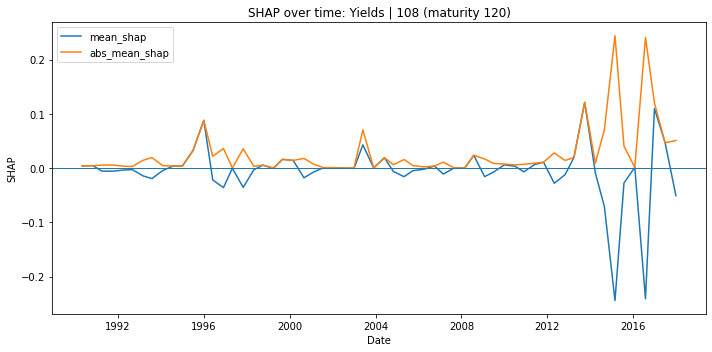

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# load saved SHAP file
shap_df = pd.read_csv(run_dir / "topk_mean_shap_test.csv")
shap_df["date"] = pd.to_datetime(shap_df["date"])

# choose what to plot
plot_maturity = "120"
plot_feature = shap_df["feature"].iloc[0]   # replace with a specific feature if you want

plot_df = shap_df[
    (shap_df["maturity"].astype(str) == str(plot_maturity)) &
    (shap_df["feature"] == plot_feature)
].copy()

plot_df = plot_df.sort_values("date")

plt.figure(figsize=(10, 5))
plt.plot(plot_df["date"], plot_df["mean_shap"], label="mean_shap")
plt.plot(plot_df["date"], plot_df["abs_mean_shap"], label="abs_mean_shap")
plt.axhline(0, linewidth=1)
plt.title(f"SHAP over time: {plot_feature} (maturity {plot_maturity})")
plt.xlabel("Date")
plt.ylabel("SHAP")
plt.legend()
plt.tight_layout()
plt.show()

Top features: ['Yields | 72', 'Yields | 48', 'Yields | 120']


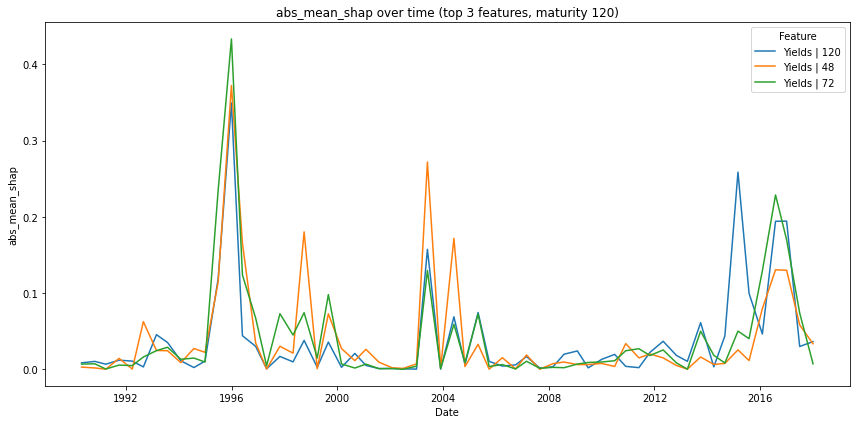

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

shap_df = pd.read_csv(run_dir / "topk_mean_shap_test.csv")
shap_df["date"] = pd.to_datetime(shap_df["date"])
shap_df["maturity"] = shap_df["maturity"].astype(str)

plot_maturity = "120"

plot_df = shap_df[shap_df["maturity"] == plot_maturity].copy()

# select top 3 features by importance
top_features = (
    plot_df.groupby("feature")["abs_mean_shap"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("Top features:", list(top_features))

plot_df = plot_df[plot_df["feature"].isin(top_features)]

wide_df = plot_df.pivot(index="date", columns="feature", values="abs_mean_shap").sort_index()

plt.figure(figsize=(12, 6))

for col in wide_df.columns:
    plt.plot(wide_df.index, wide_df[col], label=col)

plt.title(f"abs_mean_shap over time (top 3 features, maturity {plot_maturity})")
plt.xlabel("Date")
plt.ylabel("abs_mean_shap")

plt.legend(title="Feature")
plt.tight_layout()
plt.show()